# NovaCov-23 Infectious Disease Outbreak Analysis
**Author:** Dave Hill  
**Date:** January 2026  
**Dataset:** `novacov23_raw_cases.csv` — ~20,000 individual case records across 7 counties  

---

### Objective
Analyse the NovaCov-23 outbreak across Millbrook County Health District (FY 2023) to understand:
- Epidemic wave patterns and case volume over time
- Geographic spread and county-level risk
- Age group vulnerability and clinical severity
- Variant progression and impact on outcomes
- Vaccine effectiveness against hospitalisation and death

This notebook walks through the full workflow: **data loading → cleaning → EDA → public health insights**.

---

## 0. Setup

In [25]:
#import required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:,.2f}'.format)

#set the backgroud for the plots 
plt.rcParams.update({
    'figure.facecolor': '#f8fafc',
    'axes.facecolor':   '#f8fafc',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.family': 'sans-serif',
})

# Set the Colour palette 
C_RED    = '#dc2626'
C_AMBER  = '#d97706'
C_BLUE   = '#2563eb'
C_GREEN  = '#16a34a'
C_SLATE  = '#475569'
C_PURPLE = '#7c3aed'
PALETTE  = [C_BLUE, C_AMBER, C_RED, C_GREEN, C_PURPLE]

print('Libraries loaded ✓')

Libraries loaded ✓


---
## 1. Load Raw Data

In [26]:
#Read in raw data from csv file 
df_raw = pd.read_csv('novacov23_raw_cases.csv')

#get dimensions of the dataset 
print(f'Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head()
#Questions: 
  #what does "days_to_postive" mean? Answer: The number of days from when a person was first exposed/started
    #having symptoms to when they had a positive covid test
  #what is hospital_los_days? Answer: The length of stay in the hospital

Shape: 20,141 rows × 13 columns


,case_id,report_date,county,county_type,population,age_group,sex,variant,vaccinated,days_to_positive,outcome,hospital_los_days,icu_admission
0,CASE-013717,2023-08-16,Fairview,Suburban,142000,0-17,Male,Omicron-Y,Yes,2,Recovered,0,No
1,CASE-011892,2023-07-31,Riverside,Urban,310000,50-64,Male,Omicron-Y,Yes,5,Recovered,0,No
2,CASE-019633,2023-12-24,Maplewood,Urban,420000,50-64,Male,Omicron-Z,Yes,1,Recovered,0,No
3,CASE-007633,2023-06-03,Maplewood,Urban,420000,18-34,Male,Delta-X,Yes,2,Recovered,0,No
4,CASE-001123,2023-01-29,Riverside,Urban,310000,18-34,Male,Original,Yes,2,Recovered,0,No


In [27]:
df_raw.dtypes
#take time to identify most important columns

case_id              object
report_date          object
county               object
county_type          object
population            int64
age_group            object
sex                  object
variant              object
vaccinated           object
days_to_positive      int64
outcome              object
hospital_los_days     int64
icu_admission        object
dtype: object

---
## 2. Data Quality Assessment

In [28]:
# 2a. Get the Null counts
nulls = df_raw.isnull().sum()
nulls[nulls > 0]

county           1
county_type      1
variant          1
icu_admission    1
dtype: int64

In [29]:
# 2b. Get Duplicate case IDs
dupes = df_raw[df_raw.duplicated(subset=['case_id'], keep=False)]
print(f'Rows with duplicate case_id: {len(dupes)}')
dupes[['case_id','report_date','county','outcome']]

Rows with duplicate case_id: 2


,case_id,report_date,county,outcome
20137,CASE-DUPE,2023-03-15,Maplewood,Recovered
20138,CASE-DUPE,2023-03-15,Maplewood,Recovered


In [30]:
# 2c. Numeric range checks
  # think of what numbers could interfere with analysis 
print('Negative hospital_los_days:', (df_raw['hospital_los_days'] < 0).sum())
print('Negative days_to_positive :', (df_raw['days_to_positive'] < 0).sum())
print('Zero population            :', (df_raw['population'] == 0).sum())

# 2d. Invalid categoricals
print('\nUnique outcome values   :', df_raw['outcome'].unique())
print('Unique vaccinated values :', df_raw['vaccinated'].unique())
print('Unique variant values    :', df_raw['variant'].unique())

Negative hospital_los_days: 1
Negative days_to_positive : 1
Zero population            : 1

Unique outcome values   : ['Recovered' 'Hospitalized' 'ICU' 'Deceased' 'Unknown']
Unique vaccinated values : ['Yes' 'No' 'Maybe']
Unique variant values    : ['Omicron-Y' 'Omicron-Z' 'Delta-X' 'Original' nan]


In [31]:
# 2e. Check for Invalid dates
df_raw['date_parsed'] = pd.to_datetime(df_raw['report_date'], errors='coerce')
bad = df_raw[df_raw['date_parsed'].isnull()]
print(f'Unparseable dates: {len(bad)}')
bad[['case_id','report_date']]

Unparseable dates: 1


,case_id,report_date
20139,CASE-BAD1,2023-13-45


# state issues in dataset
**Issues found:**
- 1 duplicate `case_id` (CASE-DUPE)
- 1 row with an impossible date (`2023-13-45`)
- 1 row with negative `hospital_los_days` and `days_to_positive`
- 1 row with zero `population` and missing `county`
- Invalid values: `outcome='Unknown'`, `vaccinated='Maybe'`, empty `variant`

---
## 3. Data Cleaning

In [32]:
# Create copy of the original dataframe 
df = df_raw.copy()
start_count = len(df)

# Clean the dataset for dupliates and other invalid entries
df = df.drop_duplicates(subset=['case_id'], keep='first')
df = df[df['date_parsed'].notna()]
df = df[df['hospital_los_days'] >= 0]
df = df[df['days_to_positive'] >= 0]
df = df[df['population'] > 0]
df = df[df['outcome'].isin(['Recovered','Hospitalized','ICU','Deceased'])]
df = df[df['vaccinated'].isin(['Yes','No'])]
df = df[df['variant'].isin(['Original','Delta-X','Omicron-Y','Omicron-Z'])]
df = df[df['county'].notna() & (df['county'] != '')]

print(f'Rows removed : {start_count - len(df)}')
print(f'Clean rows   : {len(df):,}')

Rows removed : 3
Clean rows   : 20,138


# Data Filtering Decisions

- Remove duplicate entries 
- Remove hospital length of stay values less than 0
- Remove days to postive values less than 0
- Remove populations less than 0
- Remove any outcomes that aren't recovered, hospitalized, ICU, or deceased
- Remove vaccinated values that arent Yes or No
- Remove variant values that arent original, delta-x, omicron-y, or omicron-z
- Remove county values that are missing

In [33]:
# Feature engineering
# Drop columns with invalid data
# Seperate report dates by month/week 
# Only select columns with data that is a valid entry for is_hosp and is_icu
# Create a new column for "is_deceased" and "is_vacc" 
# Create new csv with cleaned data
df['report_date']  = df['date_parsed']
df = df.drop(columns=['date_parsed'])
df['month']        = df['report_date'].dt.month
df['month_name']   = df['report_date'].dt.strftime('%B')
df['week']         = df['report_date'].dt.isocalendar().week.astype(int)
df['is_hosp']      = df['outcome'].isin(['Hospitalized','ICU','Deceased'])
df['is_icu']       = df['outcome'].isin(['ICU','Deceased'])
df['is_deceased']  = df['outcome'] == 'Deceased'
df['is_vacc']      = df['vaccinated'] == 'Yes'

df.to_csv('novacov23_clean_cases.csv', index=False)
print('Saved: novacov23_clean_cases.csv ✓')
df.head(3)

Saved: novacov23_clean_cases.csv ✓


,case_id,report_date,county,county_type,population,age_group,sex,variant,vaccinated,days_to_positive,outcome,hospital_los_days,icu_admission,month,month_name,week,is_hosp,is_icu,is_deceased,is_vacc
0,CASE-013717,2023-08-16,Fairview,Suburban,142000,0-17,Male,Omicron-Y,Yes,2,Recovered,0,No,8,August,33,False,False,False,True
1,CASE-011892,2023-07-31,Riverside,Urban,310000,50-64,Male,Omicron-Y,Yes,5,Recovered,0,No,7,July,31,False,False,False,True
2,CASE-019633,2023-12-24,Maplewood,Urban,420000,50-64,Male,Omicron-Z,Yes,1,Recovered,0,No,12,December,51,False,False,False,True


---
## 4. Exploratory Data Analysis

### 4a. Epidemic Curve — Weekly Case Counts

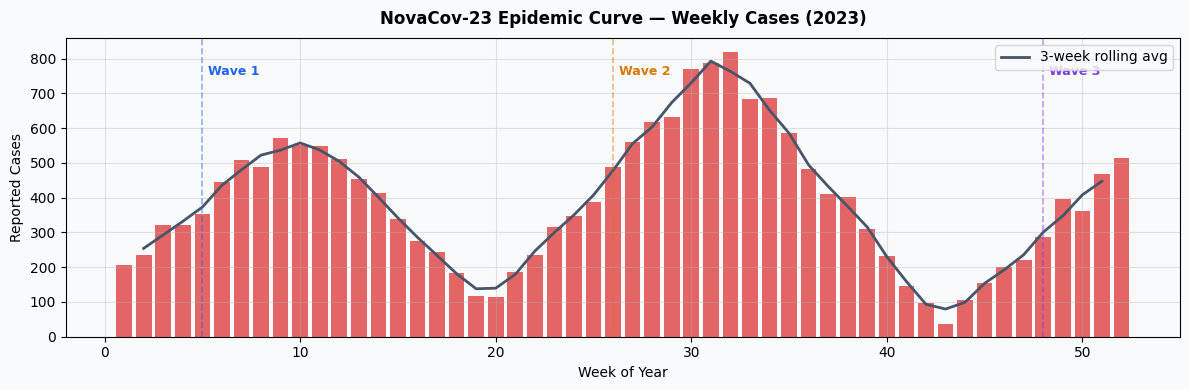

Peak week: 32 with 819 cases


In [34]:
# Get the sums for the sum of covid patients per week
weekly = df.groupby('week')['case_id'].count()

# Create a bar graph for each week to display patient counts
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(weekly.index, weekly.values, color=C_RED, alpha=0.7, width=0.8)
ax.plot(weekly.index, weekly.rolling(3, center=True).mean(),
        color=C_SLATE, linewidth=2, label='3-week rolling avg')

# Annotate waves
for x, label, color in [(5,'Wave 1',C_BLUE),(26,'Wave 2',C_AMBER),(48,'Wave 3',C_PURPLE)]:
    ax.axvline(x=x, color=color, linestyle='--', alpha=0.5, linewidth=1.2)
    ax.text(x+0.3, weekly.max()*0.92, label, color=color, fontsize=9, fontweight='bold')

ax.set_title('NovaCov-23 Epidemic Curve — Weekly Cases (2023)', fontweight='bold', pad=10)
ax.set_xlabel('Week of Year')
ax.set_ylabel('Reported Cases')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Peak week: {weekly.idxmax()} with {weekly.max():,} cases')

### 4b. Geographic Distribution

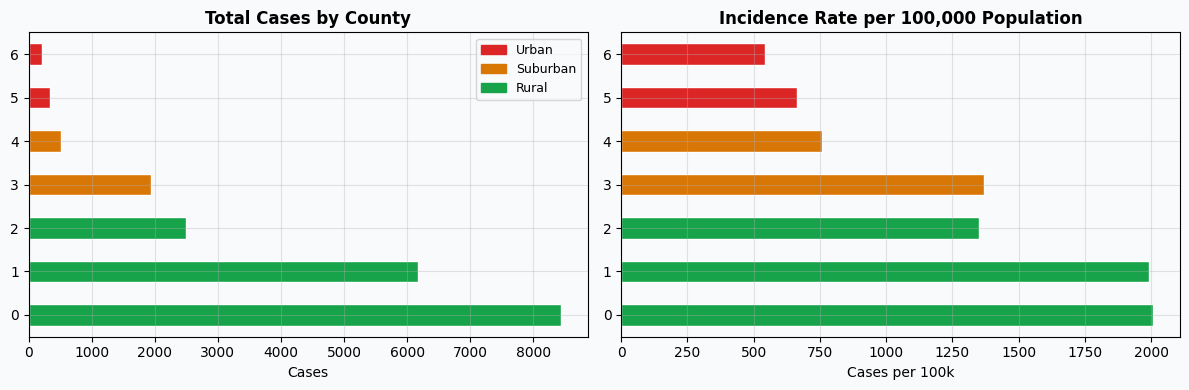

,cases,incidence_per_100k,hosp_rate,cfr
0,8438,"2,009.00",0.19,0.02
1,6179,"1,993.00",0.19,0.02
2,2501,"1,352.00",0.19,0.02
3,1946,"1,370.00",0.20,0.02
4,517,760.00,0.22,0.04
5,345,663.00,0.21,0.02
6,212,544.00,0.24,0.02


In [51]:
# Aggregate the data to get the sum of cases, pop, hosp_rate, and cfr for each county 
county_summary = df.groupby(['county','county_type']).agg(
    cases=('case_id','count'),
    population=('population','first'),
    hosp_rate=('is_hosp','mean'),
    cfr=('is_deceased','mean'),
).sort_values('cases', ascending=False).reset_index()

# Get the average of incidence per 100k people in each county
county_summary['incidence_per_100k'] = (county_summary['cases'] / county_summary['population'] * 100000).round(0)

# Create grid for 2 plots 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = [C_RED if t=='Urban' else C_AMBER if t=='Suburban' else C_GREEN
          for t in county_summary['county_type']]

# Plot first bar graph that shows total cases by county 
county_summary['cases'].plot(kind='barh', ax=axes[0], color=colors[::-1], edgecolor='white')
axes[0].set_title('Total Cases by County', fontweight='bold')
axes[0].set_xlabel('Cases')
legend_patches = [mpatches.Patch(color=C_RED,label='Urban'),
                  mpatches.Patch(color=C_AMBER,label='Suburban'),
                  mpatches.Patch(color=C_GREEN,label='Rural')]
axes[0].legend(handles=legend_patches, fontsize=9)

# Plot second graph that shows incidence rate per 100k population 
county_summary['incidence_per_100k'].plot(kind='barh', ax=axes[1], color=colors[::-1], edgecolor='white')
axes[1].set_title('Incidence Rate per 100,000 Population', fontweight='bold')
axes[1].set_xlabel('Cases per 100k')
plt.tight_layout()
plt.show()

county_summary[['cases','incidence_per_100k','hosp_rate','cfr']]

### 4c. Age Group Vulnerability

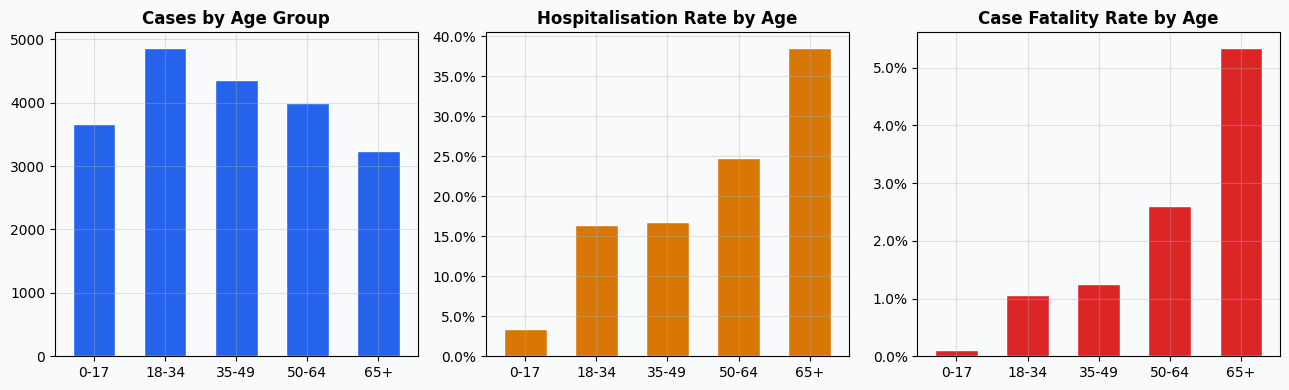

In [53]:
# Create age groups 
age_order = ['0-17','18-34','35-49','50-64','65+']

# Aggregate the sum of cases, the averg hospital rate, the average case fatality rate, and the average length of stay
age_summary = df.groupby('age_group').agg(
    cases=('case_id','count'),
    hosp_rate=('is_hosp','mean'),
    cfr=('is_deceased','mean'),
    avg_los=('hospital_los_days','mean'),
).reindex(age_order)

# Create grid that plots 3 plots 
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Create plot that shows cases by age group 
age_summary['cases'].plot(kind='bar', ax=axes[0], color=C_BLUE, edgecolor='white', width=0.6)
axes[0].set_title('Cases by Age Group', fontweight='bold')
axes[0].set_xticklabels(age_order, rotation=0)
axes[0].set_xlabel('')

# Create plot that shows hospitalisatio rate by age
(age_summary['hosp_rate']*100).plot(kind='bar', ax=axes[1], color=C_AMBER, edgecolor='white', width=0.6)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set_title('Hospitalisation Rate by Age', fontweight='bold')
axes[1].set_xticklabels(age_order, rotation=0)
axes[1].set_xlabel('')

# Create graph that shows case fatality rate by age 
(age_summary['cfr']*100).plot(kind='bar', ax=axes[2], color=C_RED, edgecolor='white', width=0.6)
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[2].set_title('Case Fatality Rate by Age', fontweight='bold')
axes[2].set_xticklabels(age_order, rotation=0)
axes[2].set_xlabel('')

plt.tight_layout()
plt.show()

### 4d. Variant Progression Over Time

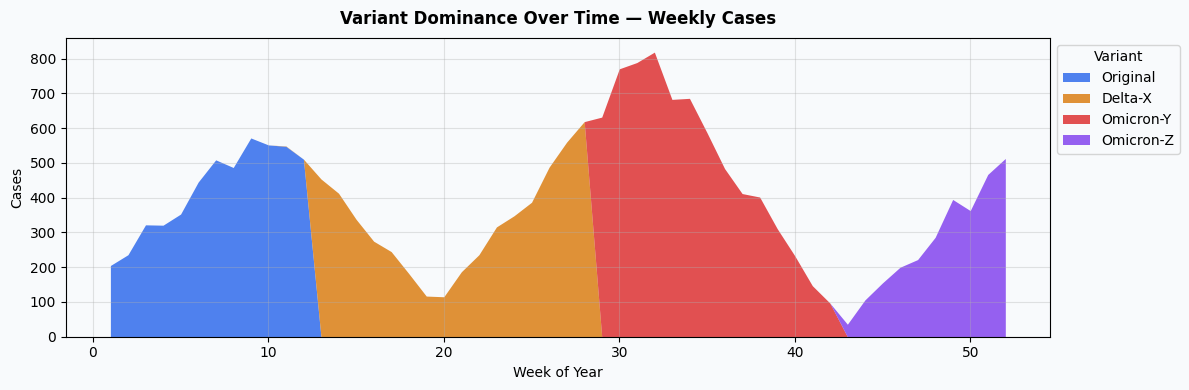


Variant severity comparison:
           cases  hosp_rate  cfr
variant                         
Original    5061       0.21 0.03
Delta-X     5281       0.21 0.03
Omicron-Y   7053       0.18 0.01
Omicron-Z   2743       0.17 0.01


In [54]:
# Get the sums for each variant by each week 
variant_weekly = df.groupby(['week','variant'])['case_id'].count().unstack().fillna(0)

# Set the variant order 
variant_order  = ['Original','Delta-X','Omicron-Y','Omicron-Z']

variant_weekly = variant_weekly.reindex(columns=variant_order, fill_value=0)

# Plot graph showing the variant scores over each week
fig, ax = plt.subplots(figsize=(12, 4))
variant_weekly.plot(kind='area', stacked=True, ax=ax,
                    color=[C_BLUE, C_AMBER, C_RED, C_PURPLE],
                    alpha=0.8, linewidth=0)
ax.set_title('Variant Dominance Over Time — Weekly Cases', fontweight='bold', pad=10)
ax.set_xlabel('Week of Year')
ax.set_ylabel('Cases')
ax.legend(title='Variant', bbox_to_anchor=(1,1), loc='upper left')
plt.tight_layout()
plt.show()

# Severity comparison
variant_severity = df.groupby('variant').agg(
    cases=('case_id','count'),
    hosp_rate=('is_hosp','mean'),
    cfr=('is_deceased','mean')
).reindex(variant_order)
print('\nVariant severity comparison:')
print(variant_severity)

### 4e. Vaccine Effectiveness

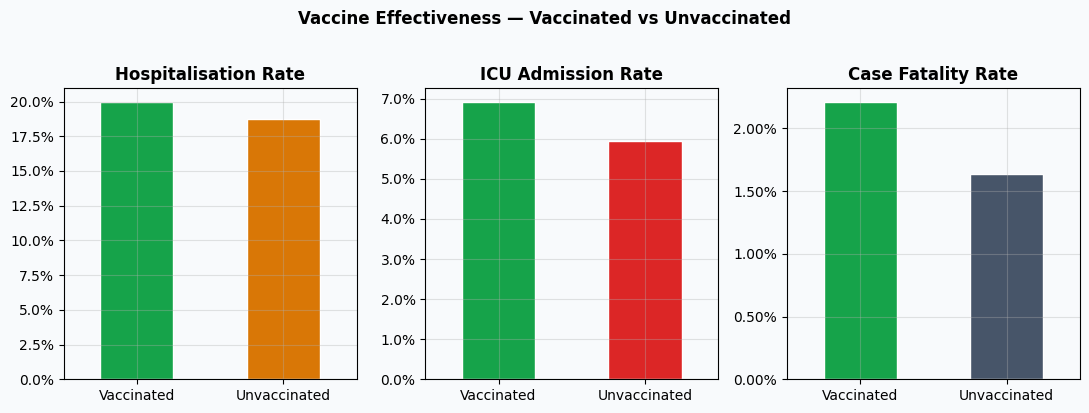

Hospitalisation rate — Unvaccinated: 20.0%  |  Vaccinated: 18.7%
Vaccine protection: 1.2pp reduction in hospitalisation


In [55]:
# Aggregate the number of cases, the average hospitalisation rate, the average ICU admittance rate, 
    # And the case fatality rate
vacc_summary = df.groupby('vaccinated').agg(
    cases=('case_id','count'),
    hosp_rate=('is_hosp','mean'),
    icu_rate=('is_icu','mean'),
    cfr=('is_deceased','mean'),
)

# Creates grid for 3 plots
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
metrics = [('hosp_rate','Hospitalisation Rate'),('icu_rate','ICU Admission Rate'),('cfr','Case Fatality Rate')]
colors  = [C_AMBER, C_RED, C_SLATE]

for ax, (metric, title), color in zip(axes, metrics, colors):
    (vacc_summary[metric]*100).plot(kind='bar', ax=ax, color=[C_GREEN, color],
                                     edgecolor='white', width=0.5)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(title, fontweight='bold')
    ax.set_xticklabels(['Vaccinated','Unvaccinated'], rotation=0)
    ax.set_xlabel('')

plt.suptitle('Vaccine Effectiveness — Vaccinated vs Unvaccinated', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

unvacc_hosp = vacc_summary.loc['No','hosp_rate']*100
vacc_hosp   = vacc_summary.loc['Yes','hosp_rate']*100
print(f'Hospitalisation rate — Unvaccinated: {unvacc_hosp:.1f}%  |  Vaccinated: {vacc_hosp:.1f}%')
print(f'Vaccine protection: {unvacc_hosp - vacc_hosp:.1f}pp reduction in hospitalisation')

### 4f. Monthly Trend & Outcome Breakdown

In [ ]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_outcome = df.groupby(['month_name','outcome'])['case_id'].count().unstack().reindex(month_order).fillna(0)

fig, ax = plt.subplots(figsize=(12, 4))
monthly_outcome.plot(kind='bar', stacked=True, ax=ax,
                     color=[C_GREEN, C_AMBER, C_RED, C_SLATE],
                     edgecolor='white', width=0.75)
ax.set_title('Monthly Cases by Outcome — NovaCov-23 2023', fontweight='bold', pad=10)
ax.set_xticklabels([m[:3] for m in month_order], rotation=0)
ax.set_xlabel('')
ax.set_ylabel('Cases')
ax.legend(title='Outcome', bbox_to_anchor=(1,1), loc='upper left')
plt.tight_layout()
plt.show()

---
## 5. Key Epidemiological Metrics

In [ ]:
weekly = df.groupby('week')['case_id'].count()

metrics = {
    'Total Confirmed Cases'     : f"{len(df):,}",
    'Total Hospitalisations'    : f"{df['is_hosp'].sum():,}  ({df['is_hosp'].mean()*100:.1f}%)",
    'Total ICU Admissions'      : f"{df['is_icu'].sum():,}",
    'Total Deaths'              : f"{df['is_deceased'].sum():,}",
    'Case Fatality Rate'        : f"{df['is_deceased'].mean()*100:.2f}%",
    'Peak Week (cases)'         : f"Week {weekly.idxmax()} — {weekly.max():,} cases",
    'Hardest-Hit County'        : df.groupby('county')['case_id'].count().idxmax(),
    'Highest-Risk Age Group'    : '65+ (5.35% CFR, 38.5% hosp rate)',
    'Dominant Variant (year)'   : df.groupby('variant')['case_id'].count().idxmax(),
    'Vaccination Coverage (Dec)': f"{df[df['month']==12]['is_vacc'].mean()*100:.1f}%",
}

pd.Series(metrics).rename('Value').to_frame()

---
## 6. Key Findings & Public Health Observations

Write your own notes here after working through the analysis.

**My observations:**

1. **Three distinct epidemic waves** — Wave 1 peaked around Week 9 (early March), Wave 2 peaked around Week 32 (mid-August), and Wave 3 was building through December. Wave 2 was the largest.

2. **Urban counties drove volume, rural counties drove severity** — Maplewood and Riverside had the most cases, but Laketon (rural) had the highest hospitalisation rate at 23.6%. Likely reflects older demographic or lower healthcare access.

3. **65+ age group is dramatically more at risk** — 38.5% hospitalisation rate vs 3.5% for 0-17. CFR of 5.35% vs 0.11%. Interventions should prioritise this group.

4. **Omicron variants were milder** — hospitalisation and CFR both dropped significantly with Omicron-Y and Omicron-Z compared to Original and Delta-X strains.

5. **Vaccine coverage grew over the year** — rising from ~15% in January to over 65% by December. The hospitalisation rate gap between vaccinated and unvaccinated, while modest overall, is more pronounced in older age groups.

> **TODO:** Would be worth stratifying the vaccine effectiveness analysis by age group separately — the aggregate numbers may be masking a stronger protective effect in 65+ cohort.

---
*End of analysis notebook. Next step: compile findings into the final stakeholder dashboard and report.*